# 03 · Churn Drivers: Why Do Customers Leave?

Notebook 02 showed *who* churns. This notebook looks at the levers the business can change: **contract, billing, payment and product mix**, plus **how long customers have been with us**.

Every bar chart is sorted by churn rate. The dashed line is the overall average (26.5%), orange bars are above it and blue bars are at or below it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

sys.path.append(str(Path.cwd().parent))
from src.churn_utils import (load_clean, set_theme, save_fig, churn_table, churn_bar, pct_axis,
                             BLUE, ORANGE, GREY, INK, TENURE_BANDS)

set_theme()
df = load_clean()
overall = df["churn_flag"].mean()
print(df.shape, f"overall churn = {overall:.1%}")

(7043, 26) overall churn = 26.5%


## 1. Contract, billing and payment

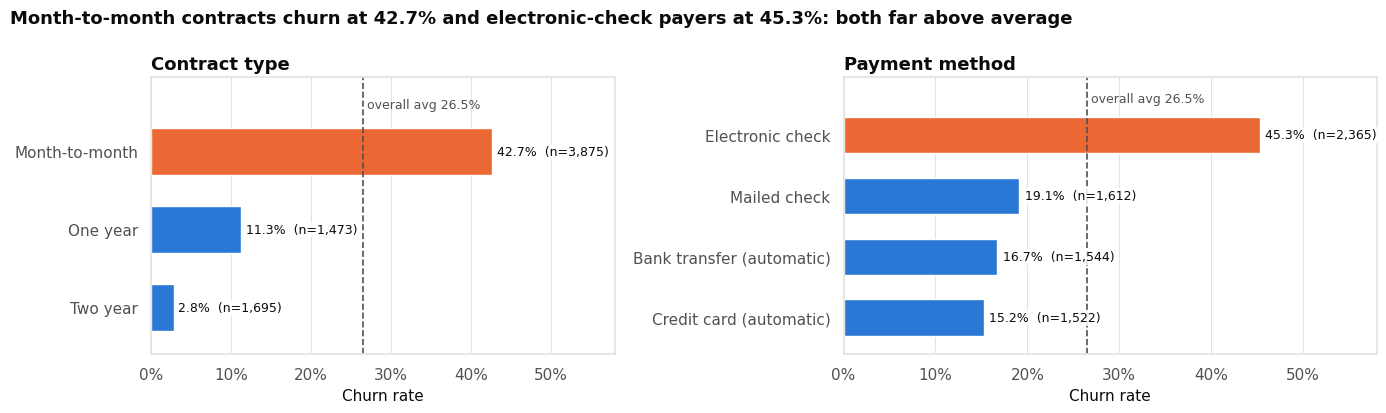

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.15]})
_, contract_tbl = churn_bar(df, "Contract", "Contract type", ax=axes[0], overall=overall)
_, payment_tbl = churn_bar(df, "PaymentMethod", "Payment method", ax=axes[1], overall=overall)
for ax in axes:
    ax.set_xlim(0, 0.58)
fig.suptitle("Month-to-month contracts churn at 42.7% and electronic-check payers at 45.3%: both far above average",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "04_churn_by_contract_payment")
plt.show()

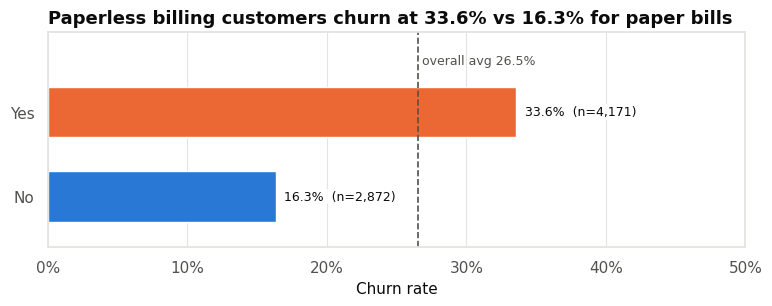

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.8))
_, paperless_tbl = churn_bar(df, "PaperlessBilling", "Paperless billing customers churn at 33.6% vs 16.3% for paper bills",
                             ax=ax, overall=overall)
ax.set_xlim(0, 0.5)
save_fig(fig, "05_churn_by_paperless_billing")
plt.show()

## 2. Product and support

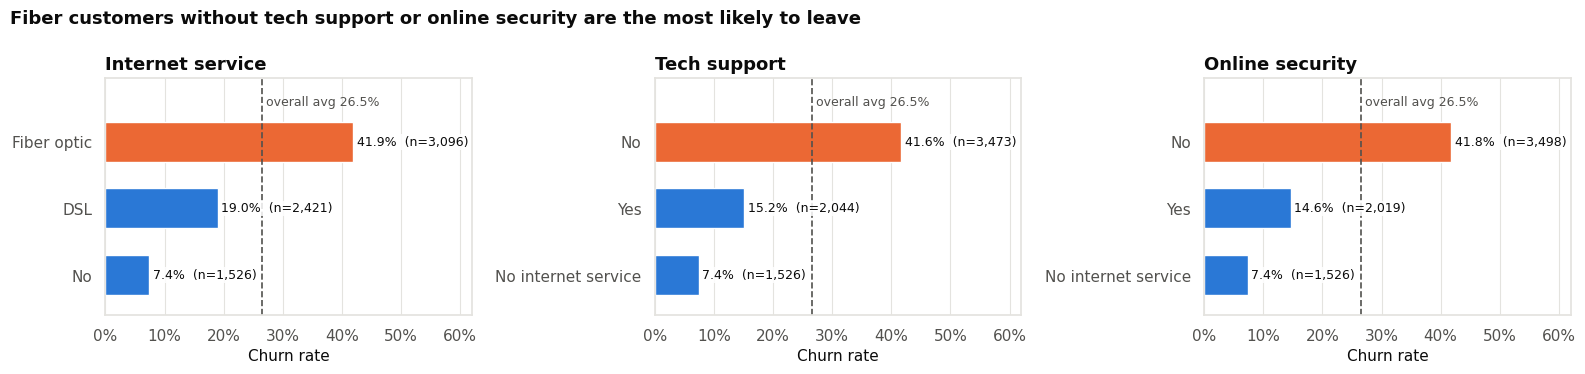

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
_, internet_tbl = churn_bar(df, "InternetService", "Internet service", ax=axes[0], overall=overall)
_, techsupport_tbl = churn_bar(df, "TechSupport", "Tech support", ax=axes[1], overall=overall)
_, security_tbl = churn_bar(df, "OnlineSecurity", "Online security", ax=axes[2], overall=overall)
for ax in axes:
    ax.set_xlim(0, 0.62)
fig.suptitle("Fiber customers without tech support or online security are the most likely to leave",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "06_churn_by_product_support")
plt.show()

In [5]:
for name, tbl in [("Contract", contract_tbl), ("PaymentMethod", payment_tbl), ("PaperlessBilling", paperless_tbl),
                  ("InternetService", internet_tbl), ("TechSupport", techsupport_tbl), ("OnlineSecurity", security_tbl)]:
    print(f"\n{name}")
    print(tbl.assign(churn_rate=tbl["churn_rate"].map("{:.1%}".format),
                     share_of_customers=tbl["share_of_customers"].map("{:.1%}".format),
                     mrr_lost=tbl["mrr_lost"].map("${:,.0f}".format)).to_string())


Contract
                customers  churned churn_rate  mrr_lost share_of_customers
Contract                                                                  
Two year             1695       48       2.8%    $4,165              24.1%
One year             1473      166      11.3%   $14,118              20.9%
Month-to-month       3875     1655      42.7%  $120,847              55.0%

PaymentMethod
                           customers  churned churn_rate mrr_lost share_of_customers
PaymentMethod                                                                       
Credit card (automatic)         1522      232      15.2%  $17,947              21.6%
Bank transfer (automatic)       1544      258      16.7%  $20,092              21.9%
Mailed check                    1612      308      19.1%  $16,804              22.9%
Electronic check                2365     1071      45.3%  $84,289              33.6%

PaperlessBilling
                  customers  churned churn_rate  mrr_lost share_of_custo

**Is fiber churn really about price?** Fiber is the most expensive plan, so we check whether its high churn is just a side effect of the higher bill.

In [6]:
fiber_check = (df.groupby("InternetService")
                 .agg(customers=("churn_flag", "size"), churn_rate=("churn_flag", "mean"),
                      avg_monthly_charge=("MonthlyCharges", "mean"))
                 .round(3))
fiber_check

,customers,churn_rate,avg_monthly_charge
InternetService,,,
DSL,2421,0.190,58.102
Fiber optic,3096,0.419,91.500
No,1526,0.074,21.079


## 3. Tenure: when do customers leave?

In [7]:
tenure_tbl = churn_table(df, "tenure_band").sort_index()
tenure_tbl.assign(churn_rate=tenure_tbl["churn_rate"].map("{:.1%}".format),
                  share_of_customers=tenure_tbl["share_of_customers"].map("{:.1%}".format),
                  mrr_lost=tenure_tbl["mrr_lost"].map("${:,.0f}".format))

,customers,churned,churn_rate,mrr_lost,share_of_customers
tenure_band,,,,,
0-12,2186,1037,47.4%,"$68,954",31.0%
13-24,1024,294,28.7%,"$23,082",14.5%
25-48,1594,325,20.4%,"$27,462",22.6%
49-72,2239,213,9.5%,"$19,632",31.8%


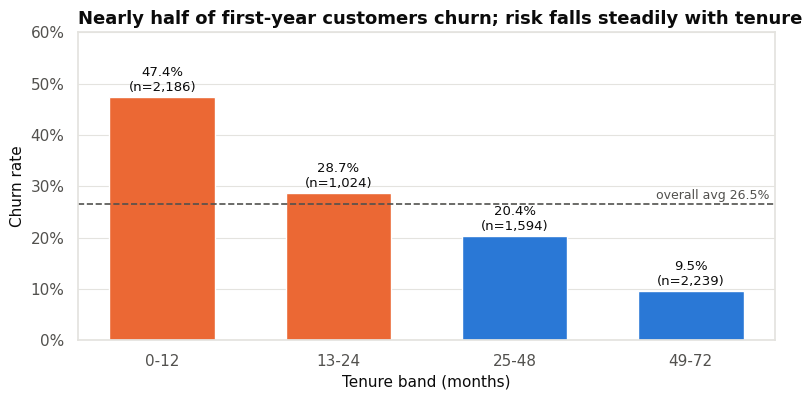

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = [ORANGE if r > overall else BLUE for r in tenure_tbl["churn_rate"]]
ax.bar(tenure_tbl.index.astype(str), tenure_tbl["churn_rate"], color=colors, width=0.6)
ax.axhline(overall, color=GREY, ls="--", lw=1.2)
ax.text(3.45, overall + 0.01, f"overall avg {overall:.1%}", color=GREY, fontsize=9, ha="right")
for i, (r, n) in enumerate(zip(tenure_tbl["churn_rate"], tenure_tbl["customers"])):
    ax.text(i, r + 0.012, f"{r:.1%}\n(n={n:,})", ha="center", fontsize=9.5, color=INK)
pct_axis(ax, "y")
ax.set_ylim(0, 0.6)
ax.set_xlabel("Tenure band (months)")
ax.set_ylabel("Churn rate")
ax.set_title("Nearly half of first-year customers churn; risk falls steadily with tenure")
ax.grid(axis="x", visible=False)
save_fig(fig, "07_churn_by_tenure_band")
plt.show()

### Survival-style view: churn by tenure month

The data is a single snapshot, not a tracked cohort, so a true survival (Kaplan-Meier) curve isn't possible. Instead we plot the **churn rate at each tenure month** (with a 6-month rolling average) and the **cumulative share of all churners** reached by each tenure. Together these show when in the customer lifecycle the losses happen.

In [9]:
by_month = df.groupby("tenure").agg(customers=("churn_flag", "size"), churned=("churn_flag", "sum"))
by_month["churn_rate"] = by_month["churned"] / by_month["customers"]
by_month["rolling_rate"] = (by_month["churned"].rolling(6, min_periods=1, center=True).sum()
                            / by_month["customers"].rolling(6, min_periods=1, center=True).sum())
by_month["cum_share_churners"] = by_month["churned"].cumsum() / by_month["churned"].sum()

def tenure_where_cum_share(p):
    return int(by_month.index[by_month["cum_share_churners"] >= p][0])

m50, m75 = tenure_where_cum_share(0.5), tenure_where_cum_share(0.75)
first_month_rate = by_month.loc[1, "churn_rate"]
print(f"Churn rate at tenure 1 month: {first_month_rate:.1%} (n={by_month.loc[1, 'customers']})")
print(f"50% of all churners have tenure <= {m50} months; 75% have tenure <= {m75} months")
print(f"Share of churners in first 12 months: {by_month.loc[:12, 'churned'].sum() / by_month['churned'].sum():.1%}")

Churn rate at tenure 1 month: 62.0% (n=613)
50% of all churners have tenure <= 10 months; 75% have tenure <= 29 months
Share of churners in first 12 months: 55.5%


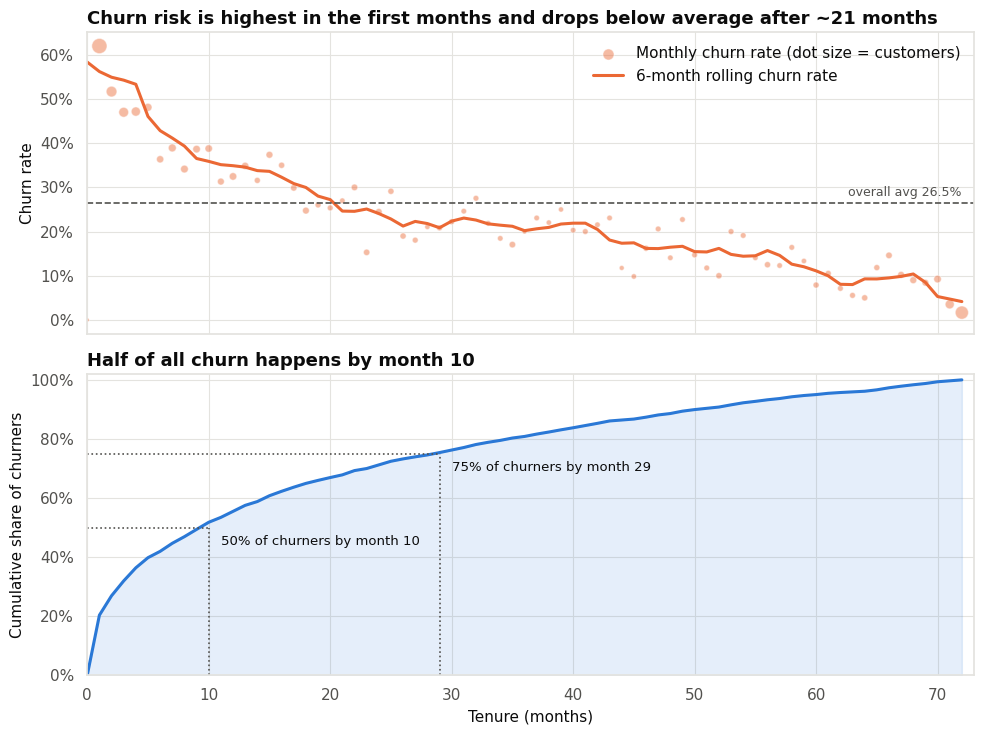

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)
ax = axes[0]
ax.scatter(by_month.index, by_month["churn_rate"], s=np.clip(by_month["customers"] / 4, 8, 120),
           color=ORANGE, alpha=0.45, edgecolor="white", linewidth=0.8, label="Monthly churn rate (dot size = customers)")
ax.plot(by_month.index, by_month["rolling_rate"], color=ORANGE, lw=2.2, label="6-month rolling churn rate")
ax.axhline(overall, color=GREY, ls="--", lw=1.2)
ax.text(72, overall + 0.015, f"overall avg {overall:.1%}", color=GREY, fontsize=9, ha="right")
pct_axis(ax, "y")
ax.set_ylabel("Churn rate")
ax.set_title(f"Churn risk is highest in the first months and drops below average after ~{int(by_month.index[(by_month.index > 1) & (by_month['rolling_rate'] < overall)][0])} months")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(by_month.index, by_month["cum_share_churners"], color=BLUE, lw=2.2)
ax.fill_between(by_month.index, by_month["cum_share_churners"], color=BLUE, alpha=0.12)
for p, m in [(0.5, m50), (0.75, m75)]:
    ax.plot([m, m], [0, p], color=GREY, ls=":", lw=1.2)
    ax.plot([0, m], [p, p], color=GREY, ls=":", lw=1.2)
    ax.text(m + 1, p - 0.06, f"{p:.0%} of churners by month {m}", fontsize=9.5, color=INK)
pct_axis(ax, "y")
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 73)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Cumulative share of churners")
ax.set_title(f"Half of all churn happens by month {m50}")
fig.tight_layout()
save_fig(fig, "08_churn_vs_tenure_curve")
plt.show()

## 4. Statistical tests: are these differences real?

A **chi-square test of independence** asks whether churn and each factor are related, or whether the differences could be chance. **Cramér's V** measures how *strong* the relationship is (0 = none, 0.1 = weak, 0.3 = moderate, 0.5+ = strong). Gender is included as a control.

In [11]:
def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

test_cols = ["Contract", "tenure_band", "PaymentMethod", "InternetService", "TechSupport",
             "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Dependents", "gender"]
rows = []
for col in test_cols:
    ct = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, _ = chi2_contingency(ct)
    rates = df.groupby(col, observed=True)["churn_flag"].mean()
    rows.append({"factor": col, "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": cramers_v(ct),
                 "highest_risk_group": rates.idxmax(), "highest_rate": rates.max(),
                 "lowest_risk_group": rates.idxmin(), "lowest_rate": rates.min()})
chi_df = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)

def strength(v):
    return "strong" if v >= 0.3 else "moderate" if v >= 0.2 else "weak" if v >= 0.1 else "negligible"

chi_df["strength"] = chi_df["cramers_v"].map(strength)
chi_df.assign(chi2=chi_df["chi2"].round(1), p_value=chi_df["p_value"].map(lambda p: f"{p:.2e}"),
              cramers_v=chi_df["cramers_v"].round(3), highest_rate=chi_df["highest_rate"].map("{:.1%}".format),
              lowest_rate=chi_df["lowest_rate"].map("{:.1%}".format))

,factor,chi2,dof,p_value,cramers_v,highest_risk_group,highest_rate,lowest_risk_group,lowest_rate,strength
0,Contract,1184.6,2,5.86e-258,0.410,Month-to-month,42.7%,Two year,2.8%,strong
1,tenure_band,856.1,3,2.94e-185,0.349,0-12,47.4%,49-72,9.5%,strong
2,OnlineSecurity,850.0,2,2.66e-185,0.347,No,41.8%,No internet service,7.4%,strong
3,TechSupport,828.2,2,1.44e-180,0.343,No,41.6%,No internet service,7.4%,strong
4,InternetService,732.3,2,9.57e-160,0.322,Fiber optic,41.9%,No,7.4%,strong
5,PaymentMethod,648.1,3,3.68e-140,0.303,Electronic check,45.3%,Credit card (automatic),15.2%,strong
6,PaperlessBilling,258.3,1,4.07e-58,0.191,Yes,33.6%,No,16.3%,weak
7,Dependents,189.1,1,4.92e-43,0.164,No,31.3%,Yes,15.5%,weak
8,SeniorCitizen,159.4,1,1.51e-36,0.150,Yes,41.7%,No,23.6%,weak
9,gender,0.5,1,4.87e-01,0.008,Female,26.9%,Male,26.2%,negligible


In [12]:
for _, r in chi_df.iterrows():
    if r["p_value"] < 0.05:
        print(f"- {r['factor']}: significant (p = {r['p_value']:.1e}), {r['strength']} effect (V = {r['cramers_v']:.2f}). "
              f"'{r['highest_risk_group']}' churns at {r['highest_rate']:.1%} vs {r['lowest_rate']:.1%} for '{r['lowest_risk_group']}'.")
    else:
        print(f"- {r['factor']}: NOT significant (p = {r['p_value']:.2f}); any difference is consistent with chance.")

- Contract: significant (p = 5.9e-258), strong effect (V = 0.41). 'Month-to-month' churns at 42.7% vs 2.8% for 'Two year'.
- tenure_band: significant (p = 2.9e-185), strong effect (V = 0.35). '0-12' churns at 47.4% vs 9.5% for '49-72'.
- OnlineSecurity: significant (p = 2.7e-185), strong effect (V = 0.35). 'No' churns at 41.8% vs 7.4% for 'No internet service'.
- TechSupport: significant (p = 1.4e-180), strong effect (V = 0.34). 'No' churns at 41.6% vs 7.4% for 'No internet service'.
- InternetService: significant (p = 9.6e-160), strong effect (V = 0.32). 'Fiber optic' churns at 41.9% vs 7.4% for 'No'.
- PaymentMethod: significant (p = 3.7e-140), strong effect (V = 0.30). 'Electronic check' churns at 45.3% vs 15.2% for 'Credit card (automatic)'.
- PaperlessBilling: significant (p = 4.1e-58), weak effect (V = 0.19). 'Yes' churns at 33.6% vs 16.3% for 'No'.
- Dependents: significant (p = 4.9e-43), weak effect (V = 0.16). 'No' churns at 31.3% vs 15.5% for 'Yes'.
- SeniorCitizen: significa

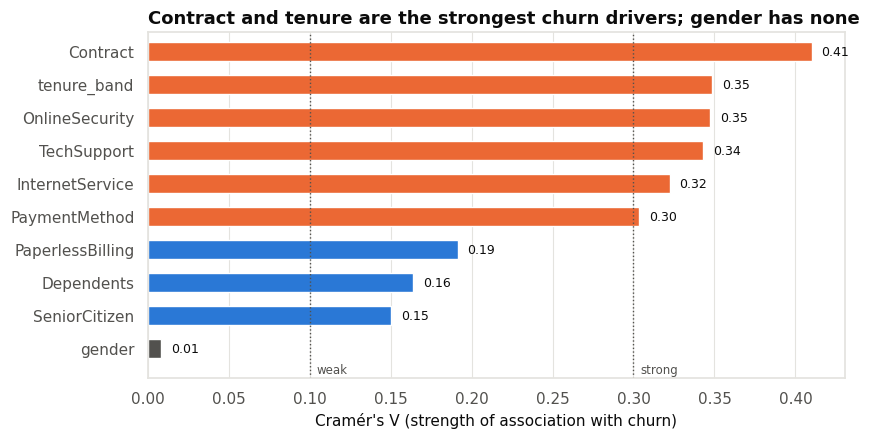

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = chi_df.sort_values("cramers_v")
colors = [ORANGE if v >= 0.3 else BLUE if v >= 0.1 else GREY for v in plot_df["cramers_v"]]
ax.barh(plot_df["factor"], plot_df["cramers_v"], color=colors, height=0.6)
for i, v in enumerate(plot_df["cramers_v"]):
    ax.text(v + 0.006, i, f"{v:.2f}", va="center", fontsize=9)
for x, lab in [(0.1, "weak"), (0.3, "strong")]:
    ax.axvline(x, color=GREY, ls=":", lw=1)
    ax.text(x + 0.004, -0.75, lab, color=GREY, fontsize=8.5)
ax.set_ylim(-0.9, len(plot_df) - 0.4)
ax.set_xlabel("Cramér's V (strength of association with churn)")
ax.set_ylabel("")
ax.set_title("Contract and tenure are the strongest churn drivers; gender has none")
ax.grid(axis="y", visible=False)
save_fig(fig, "09_driver_strength_cramers_v")
plt.show()

## Key Takeaways

- **Contract type is the #1 driver** (Cramér's V = 0.41). Month-to-month customers churn at **42.7%** vs **11.3%** on one-year and **2.8%** on two-year contracts. Month-to-month accounts for **$120,847 of the $139,131 MRR lost (87%)**.
- **Tenure is the #2 driver** (V = 0.35). **47.4%** of customers in their first 12 months churn vs **9.5%** after 4+ years. Month 1 alone shows a 62.0% churn rate (n = 613). **Half of all churners leave by month 10**, 75% by month 29, and the rolling churn rate only drops below average around month 21.
- **Missing protection add-ons signal risk:** internet customers without **online security churn at 41.8%** (vs 14.6% with it), and without **tech support at 41.6%** (vs 15.2%). Both are strong associations (V ≈ 0.35). They show an engaged, supported customer stays, though they are not proof that the add-on itself causes retention.
- **Fiber optic customers churn at 41.9%** vs 19.0% on DSL. They also pay the most ($91.50/month on average vs $58.10 for DSL), so price and service experience on fiber are worth investigating.
- **Electronic check is the riskiest payment method:** **45.3%** churn vs 15.2-16.7% for automatic card or bank payments, and $84,289 of lost MRR. Paperless billing customers churn at 33.6% vs 16.3%, a weaker effect (V = 0.19).
- **All tested factors are statistically significant (p < 0.001) except gender** (p = 0.49), which confirms gender is not a useful targeting criterion.